para hacer figura que represente los resultados del test de mantel

/tmp/ipykernel_58215/3101256932.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='Index', x='Coef_corr', palette='vlag', edgecolor='black')


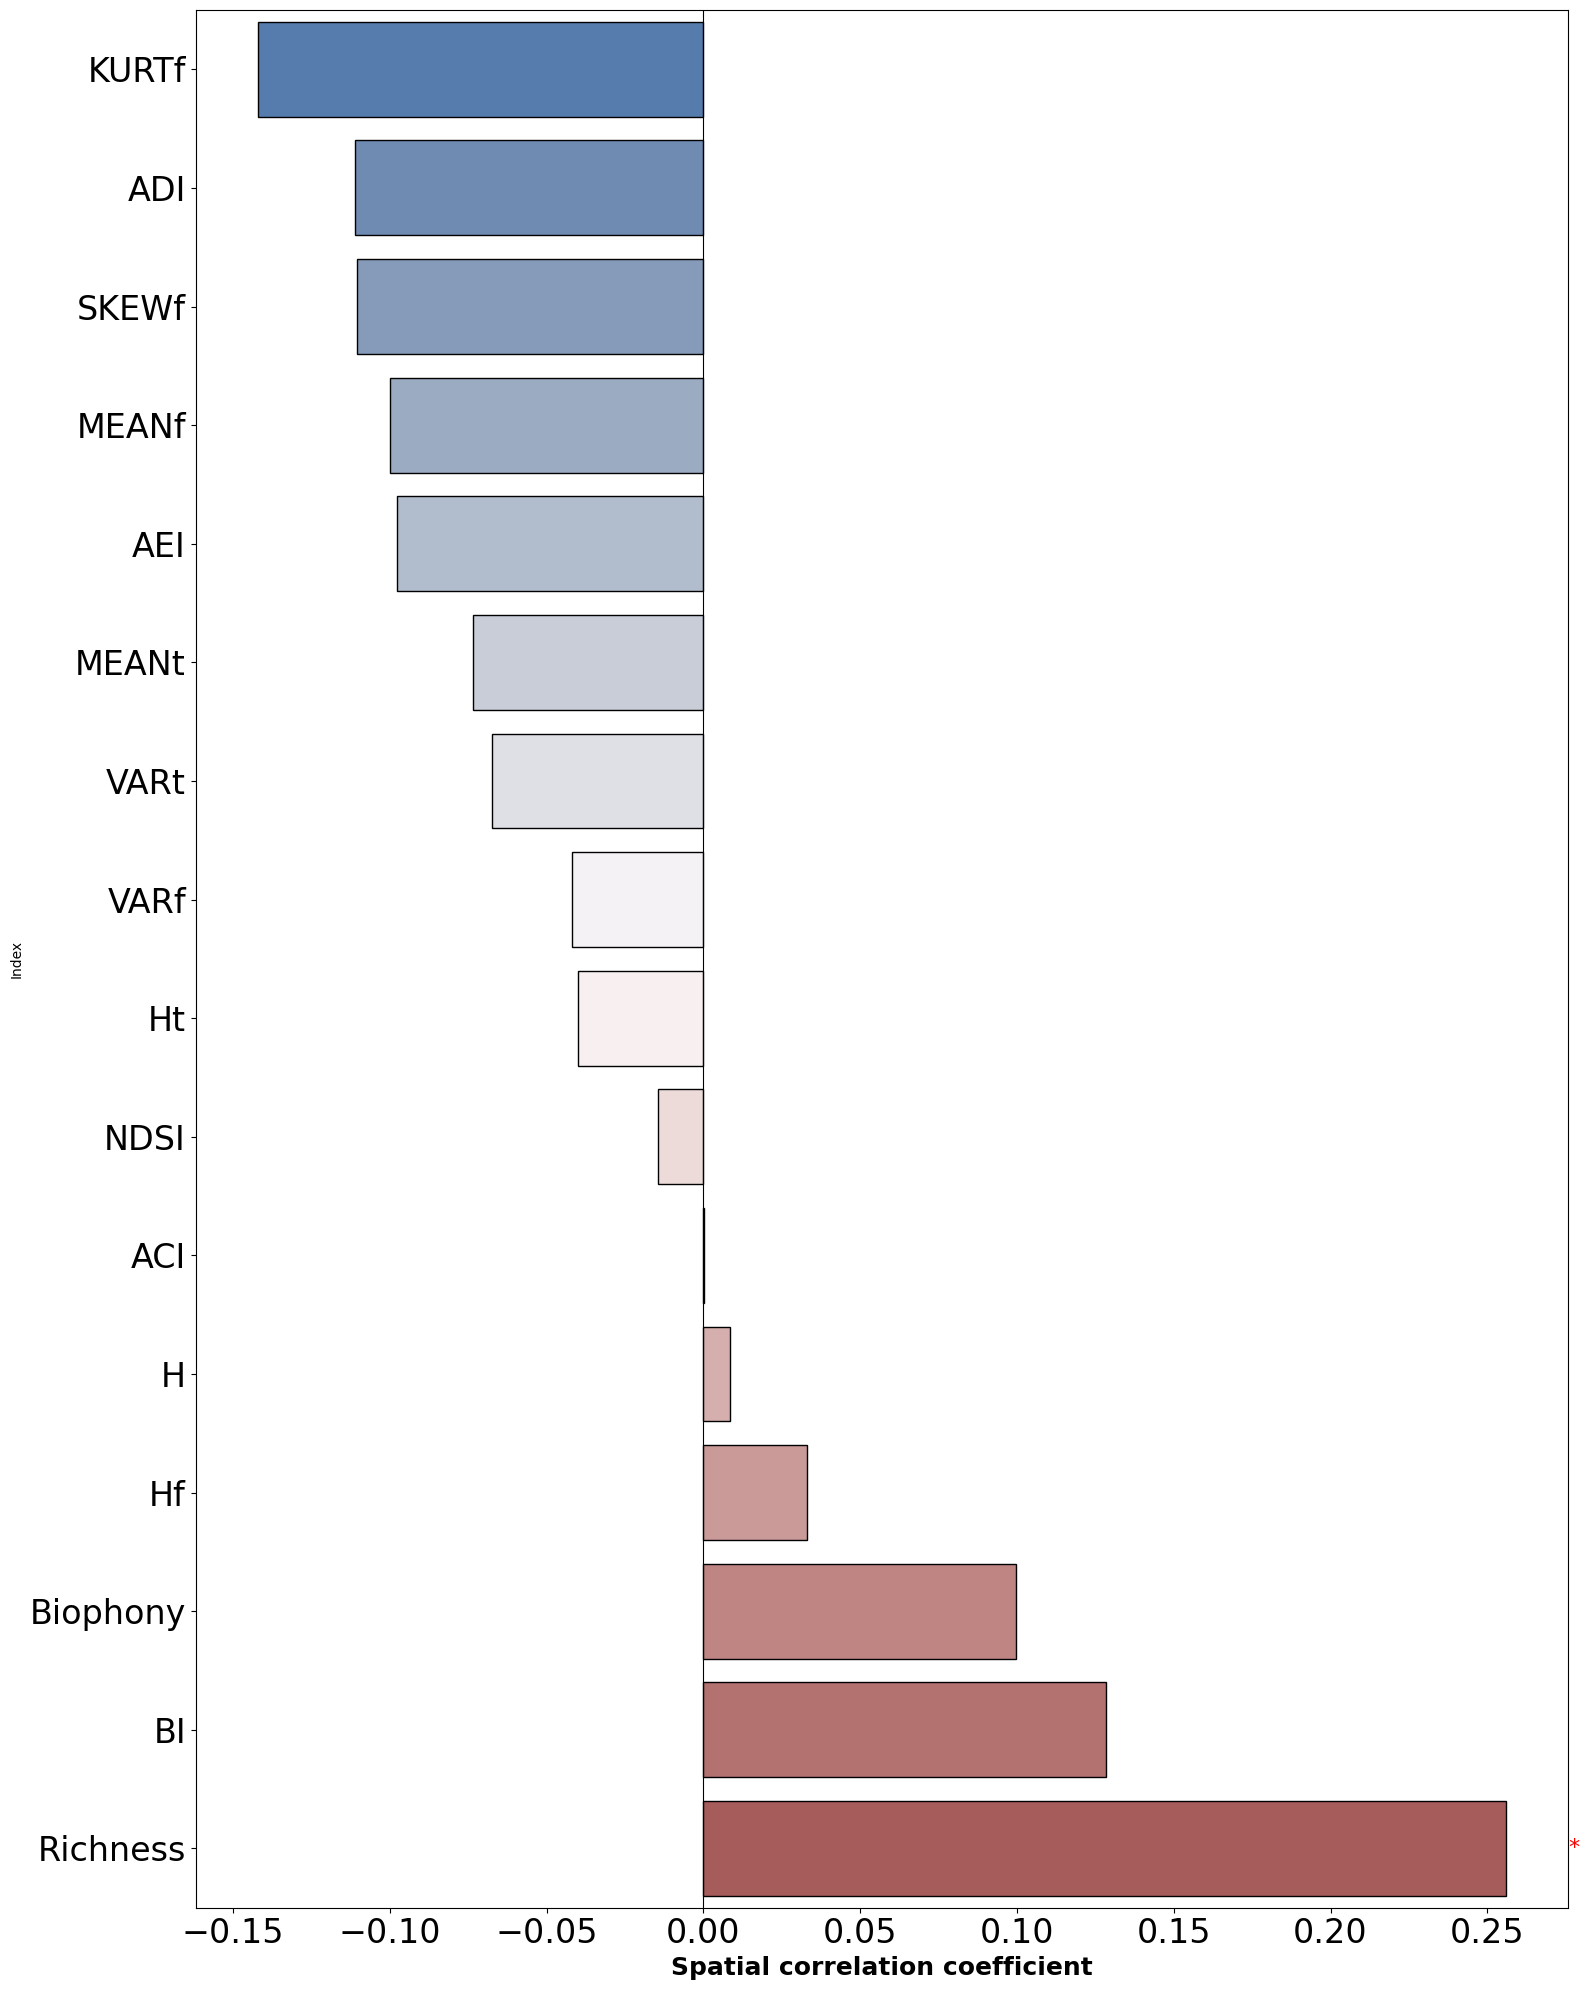

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos
data = {
    'Index': ['Biophony', 'Richness', 'ACI', 'ADI', 'AEI', 'BI', 'H', 'Hf', 'Ht', 
               'KURTf', 'MEANf', 'MEANt', 'NDSI', 'SKEWf', 'VARf', 'VARt'],
    'Coef_corr': [0.0997658190389271, 0.2559642879733742, 0.00019890311733664935, -0.1109406432928508,
                  -0.09780785440550967, 0.12841690611708073, 0.008556721402817697, 0.03312611559057056,
                  -0.0398149617905168, -0.14198119166939321, -0.09975282886233248, -0.07353778673309727,
                  -0.014545843281188754, -0.11045472362509029, -0.041769006747804455, -0.0672597046256313],
    'p_value': [0.1907, 0.006, 0.9978, 0.158, 0.2183, 0.0889, 0.915, 0.6909, 0.6402,
                0.0705, 0.2315, 0.3845, 0.8469, 0.1639, 0.6281, 0.4254]
}

df = pd.DataFrame(data)

# Crear columna para significancia con asterisco
df['significativo'] = df['p_value'] < 0.05
df['label'] = df.apply(lambda row: '*' if row['significativo'] else '', axis=1)

# Ordenar para mejor visualización si se quiere (opcional)
df = df.sort_values('Coef_corr')

# Figura
plt.figure(figsize=(16,20))
sns.barplot(data=df, y='Index', x='Coef_corr', palette='vlag', edgecolor='black')

# Añadir asteriscos en barras significativas
for i, row in enumerate(df.itertuples()):
    if row.significativo:
        xpos = row.Coef_corr + 0.02 if row.Coef_corr >= 0 else row.Coef_corr - 0.04
        plt.text(xpos, i, row.label, color='red', fontsize=16, va='center', ha='left')

plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Spatial correlation coefficient', fontsize=18, fontweight='bold')
#plt.ylabel('Índice', fontsize=18)
plt.yticks(fontsize=24)
plt.xticks(fontsize=24)
#plt.title('Coeficientes de correlación con significancia (*)')
plt.tight_layout()
plt.show()

